# PHẦN A: ĐỌC DỮ LIỆU

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, desc
from pyspark.sql import functions as F

In [8]:

# Khởi tạo SparkSession
spark = SparkSession.builder.appName("RetailAnalysis").getOrCreate()
df = spark.read.csv("../data/retail_transactions.csv", 
                     header=True, 
                     inferSchema=True,
                     samplingRatio=0.1) # Chỉ quét 10% dữ liệu để đoán kiểu
#df = spark.read.csv("../data/retail_transactions_large.csv")

df.show(10)

print("Schema chuẩn của Parquet:")
df.printSchema()

+--------------+--------+----------+--------+-------------+------------------+-------------------+
|transaction_id|store_id|product_id|quantity|     category|             price|   transaction_date|
+--------------+--------+----------+--------+-------------+------------------+-------------------+
|        620486|       8|        92|       7|      Grocery|20.939999999999998|2025-01-01 00:01:31|
|        177622|      27|        72|       3|  Electronics|            227.56|2025-01-01 00:02:20|
|        923797|      44|       334|       4|      Fashion|            212.43|2025-01-01 00:04:38|
|        286596|       3|       162|       4|Home & Garden|             14.72|2025-01-01 00:04:40|
|        224889|      12|       322|       9|       Beauty|             46.33|2025-01-01 00:05:40|
|        111718|       2|       403|       7|       Beauty|             45.51|2025-01-01 00:05:42|
|        300751|      40|       182|       6|Home & Garden|              86.8|2025-01-01 00:07:17|
|        3

# PHẦN B: LÀM SẠCH DỮ LIỆU 

In [9]:
# 1. Loại bỏ các dòng null ở các cột quan trọng
df_clean = df.dropna(subset=["store_id", "product_id", "quantity", "price"])

# 2. Loại bỏ các dòng có quantity <= 0 hoặc price <= 0
df_clean = df_clean.filter((col("quantity") > 0) & (col("price") > 0))

print(f"Số lượng bản ghi sau khi làm sạch: {df_clean.count()}")

Số lượng bản ghi sau khi làm sạch: 1000000


#  PHẦN C: TẠO BIẾN MỚI 

In [10]:

# Tạo cột revenue = quantity * price và làm tròn 2 chữ số thập phân
df_clean = df_clean.withColumn("revenue", F.round(F.col("quantity") * F.col("price"), 2))

print("Dữ liệu sau khi thêm cột Revenue (5 dòng đầu):")
df_clean.show(5)

Dữ liệu sau khi thêm cột Revenue (5 dòng đầu):
+--------------+--------+----------+--------+-------------+------------------+-------------------+-------+
|transaction_id|store_id|product_id|quantity|     category|             price|   transaction_date|revenue|
+--------------+--------+----------+--------+-------------+------------------+-------------------+-------+
|        620486|       8|        92|       7|      Grocery|20.939999999999998|2025-01-01 00:01:31| 146.58|
|        177622|      27|        72|       3|  Electronics|            227.56|2025-01-01 00:02:20| 682.68|
|        923797|      44|       334|       4|      Fashion|            212.43|2025-01-01 00:04:38| 849.72|
|        286596|       3|       162|       4|Home & Garden|             14.72|2025-01-01 00:04:40|  58.88|
|        224889|      12|       322|       9|       Beauty|             46.33|2025-01-01 00:05:40| 416.97|
+--------------+--------+----------+--------+-------------+------------------+-------------------

# PHẦN D: PHÂN TÍCH 

/tmp/ipykernel_2039/206699442.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=top_stores_pd, x='store_id', y='store_revenue', palette='viridis')
/tmp/ipykernel_2039/206699442.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], data=top_products_pd, x='product_id', y='product_revenue', palette='magma')


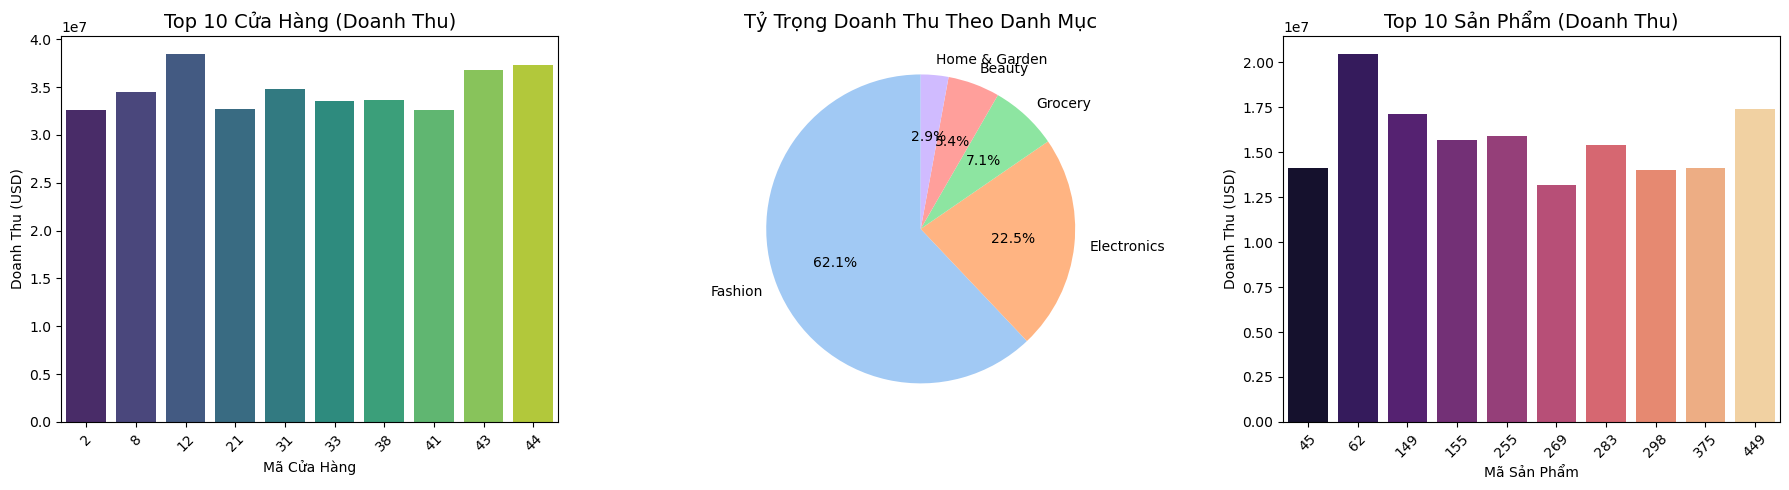

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# --- BƯỚC 1: LẤY DỮ LIỆU TỪ SPARK VỀ PANDAS ---

# (Bỏ qua tổng doanh thu vì nó là 1 con số, không cần vẽ biểu đồ)

# Lấy Top 10 cửa hàng
top_stores_pd = df_clean.groupBy("store_id") \
    .agg(F.round(F.sum("revenue"), 2).alias("store_revenue")) \
    .orderBy(F.desc("store_revenue")) \
    .limit(10).toPandas()

# Lấy Doanh thu theo danh mục
category_pd = df_clean.groupBy("category") \
    .agg(F.round(F.sum("revenue"), 2).alias("category_revenue")) \
    .orderBy(F.desc("category_revenue")).toPandas()

# Lấy Top 10 sản phẩm
top_products_pd = df_clean.groupBy("product_id") \
    .agg(F.round(F.sum("revenue"), 2).alias("product_revenue")) \
    .orderBy(F.desc("product_revenue")) \
    .limit(10).toPandas()

# --- BƯỚC 2: VẼ BIỂU ĐỒ TRỰC QUAN ---

# Tạo một khung ảnh lớn chứa 3 biểu đồ nằm ngang nhau
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Top 10 Cửa hàng (Bar Chart)
sns.barplot(ax=axes[0], data=top_stores_pd, x='store_id', y='store_revenue', palette='viridis')
axes[0].set_title('Top 10 Cửa Hàng (Doanh Thu)', fontsize=14)
axes[0].set_xlabel('Mã Cửa Hàng')
axes[0].set_ylabel('Doanh Thu (USD)')
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ 2: Cơ cấu theo Danh mục (Pie Chart)
axes[1].pie(category_pd['category_revenue'], labels=category_pd['category'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('Tỷ Trọng Doanh Thu Theo Danh Mục', fontsize=14)

# Biểu đồ 3: Top 10 Sản phẩm (Bar Chart)
sns.barplot(ax=axes[2], data=top_products_pd, x='product_id', y='product_revenue', palette='magma')
axes[2].set_title('Top 10 Sản Phẩm (Doanh Thu)', fontsize=14)
axes[2].set_xlabel('Mã Sản Phẩm')
axes[2].set_ylabel('Doanh Thu (USD)')
axes[2].tick_params(axis='x', rotation=45)

# Tự động căn chỉnh khoảng cách và hiển thị
plt.tight_layout()
plt.show()

In [12]:
# 1. Tính tổng doanh thu toàn bộ hệ thống
total_system_revenue = df_clean.select(sum("revenue")).collect()[0][0]
print(f"\n[1] Tổng doanh thu toàn bộ hệ thống: {round(total_system_revenue, 2)} USD")

# 2. Tính doanh thu theo từng cửa hàng
print("\n[2] Doanh thu theo từng cửa hàng (Top 10):")
df_clean.groupBy("store_id") \
    .agg(F.round(F.sum("revenue"), 2).alias("store_revenue")) \
    .orderBy(F.desc("store_revenue")) \
    .show(10)

# 3. Tính doanh thu theo từng danh mục sản phẩm
print("\n[3] Doanh thu theo từng danh mục sản phẩm:")
df_clean.groupBy("category") \
    .agg(F.round(F.sum("revenue"), 2).alias("category_revenue")) \
    .orderBy(desc("category_revenue")) \
    .show()

# 4. Tìm 10 sản phẩm có doanh thu cao nhất
print("\n[4] Top 10 sản phẩm có doanh thu cao nhất:")
df_clean.groupBy("product_id") \
    .agg(F.round(F.sum("revenue"), 2).alias("product_revenue")) \
    .orderBy(desc("product_revenue")) \
    .limit(10) \
    .show()


[1] Tổng doanh thu toàn bộ hệ thống: 685369116.8 USD

[2] Doanh thu theo từng cửa hàng (Top 10):
+--------+-------------+
|store_id|store_revenue|
+--------+-------------+
|      12|3.843910807E7|
|      44|3.735319525E7|
|      43|3.678447981E7|
|      31|3.477827774E7|
|       8|3.449430704E7|
|      38|3.367038422E7|
|      33|3.357361572E7|
|      21|3.275754171E7|
|       2|3.261167874E7|
|      41|3.259784731E7|
+--------+-------------+
only showing top 10 rows


[3] Doanh thu theo từng danh mục sản phẩm:
+-------------+----------------+
|     category|category_revenue|
+-------------+----------------+
|      Fashion|  4.2541864978E8|
|  Electronics|  1.5428867233E8|
|      Grocery|   4.856929953E7|
|       Beauty|   3.726065235E7|
|Home & Garden|   1.983184281E7|
+-------------+----------------+


[4] Top 10 sản phẩm có doanh thu cao nhất:
+----------+---------------+
|product_id|product_revenue|
+----------+---------------+
|        62|  2.043342936E7|
|       449|  1.73769149